In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("adult_with_headers.csv")

# Clean whitespace from all string columns
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution (income):\n", df['income'].value_counts())

Shape: (32561, 15)

Data Types:
 age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Summary Statistics:
                 age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000

In [10]:
# In the Adult dataset, missing values are encoded as '?'
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

print("\nMissing Values Before:\n", df.isnull().sum())

# Columns with missing values: workclass, occupation, native_country
# Strategy: fill with Mode (most frequent value) — suitable for categorical data
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

print("\nMissing Values After:\n", df.isnull().sum())


Missing Values Before:
 age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Missing Values After:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


C:\Users\akshara\AppData\Local\Temp\ipykernel_1248\1632051897.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [11]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numerical_cols = ['age', 'fnlwgt', 'education_num',
                  'capital_gain', 'capital_loss', 'hours_per_week']

# ── a) Standard Scaling (Z-score) ────────────────────────────────
std_scaler = StandardScaler()
df_standard = df.copy()
df_standard[numerical_cols] = std_scaler.fit_transform(df[numerical_cols])

# ── b) Min-Max Scaling ────────────────────────────────────────────
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df[numerical_cols])

print("Standard Scaled Sample:\n", df_standard[numerical_cols].head(3))
print("\nMin-Max Scaled Sample:\n", df_minmax[numerical_cols].head(3))

Standard Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   

   hours_per_week  
0       -0.035429  
1       -2.222153  
2       -0.035429  

Min-Max Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.048238       0.800000       0.00000           0.0   
2  0.287671  0.138113       0.533333       0.00000           0.0   

   hours_per_week  
0        0.397959  
1        0.122449  
2        0.397959  


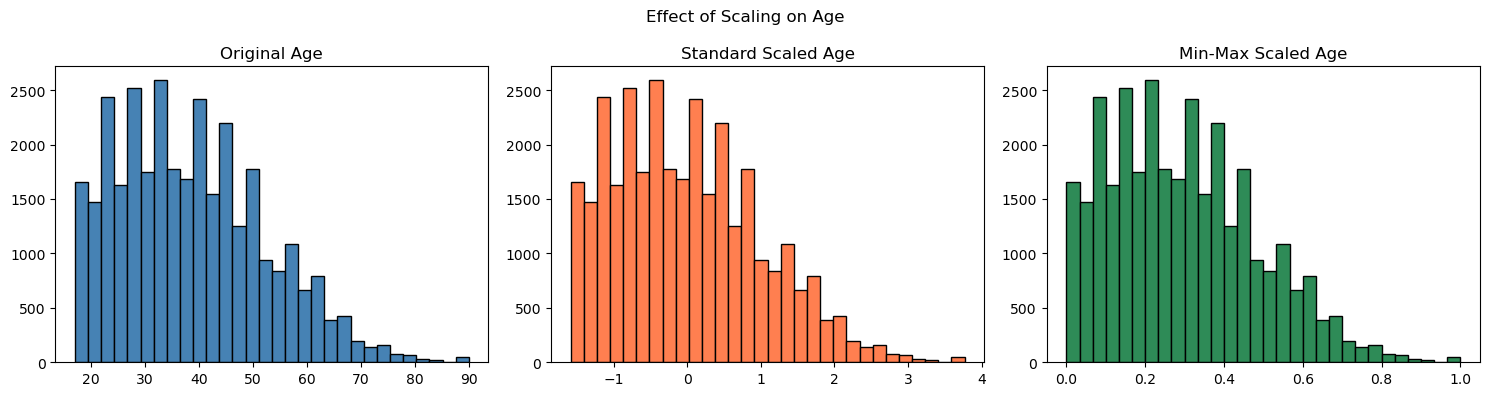

In [12]:
# Visualize effect of scaling on 'age'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Original Age')
axes[1].hist(df_standard['age'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Standard Scaled Age')
axes[2].hist(df_minmax['age'], bins=30, color='seagreen', edgecolor='black')
axes[2].set_title('Min-Max Scaled Age')
plt.suptitle('Effect of Scaling on Age')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Identify categorical columns and their unique counts
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
cat_cols.remove('income')  # target column

print("Categorical columns and unique counts:")
for col in cat_cols:
    print(f"  {col}: {df_encoded[col].nunique()} unique values")

Categorical columns and unique counts:
  workclass: 8 unique values
  education: 16 unique values
  marital_status: 7 unique values
  occupation: 14 unique values
  relationship: 6 unique values
  race: 5 unique values
  sex: 2 unique values
  native_country: 41 unique values


In [15]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Identify categorical columns and their unique counts
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
cat_cols.remove('income')  # target column

print("Categorical columns and unique counts:")
for col in cat_cols:
    print(f"  {col}: {df_encoded[col].nunique()} unique values")

# ── One-Hot Encoding: columns with < 5 categories ─────────────────
ohe_cols = [col for col in cat_cols if df_encoded[col].nunique() < 5]
print("\nOne-Hot Encoding:", ohe_cols)

df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# ── Label Encoding: columns with >= 5 categories ──────────────────
le_cols = [col for col in cat_cols 
           if col in df_encoded.columns          # ← check existence FIRST
           and df_encoded[col].nunique() >= 5]   # ← then check unique count

print("Label Encoding:", le_cols)

le = LabelEncoder()
for col in le_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Encode target
df_encoded['income'] = (df_encoded['income'] == '>50K').astype(int)

print("\nEncoded DataFrame shape:", df_encoded.shape)
print(df_encoded.head(3))

Categorical columns and unique counts:
  workclass: 8 unique values
  education: 16 unique values
  marital_status: 7 unique values
  occupation: 14 unique values
  relationship: 6 unique values
  race: 5 unique values
  sex: 2 unique values
  native_country: 41 unique values

One-Hot Encoding: ['sex']
Label Encoding: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']

Encoded DataFrame shape: (32561, 15)
   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          6   77516          9             13               4   
1   50          5   83311          9             13               2   
2   38          3  215646         11              9               0   

   occupation  relationship  race  capital_gain  capital_loss  hours_per_week  \
0           0             1     4          2174             0              40   
1           3             0     4             0             0              13   
2           5

In [16]:
df_feat = df_encoded.copy()

# ── New Feature 1: capital_net ────────────────────────────────────
# Rationale: capital_gain and capital_loss together reflect actual
# financial activity. Their net value is more informative than each alone.
df_feat['capital_net'] = df['capital_gain'] - df['capital_loss']
print("capital_net sample:\n", df_feat['capital_net'].describe())

# ── New Feature 2: work_intensity ────────────────────────────────
# Rationale: hours_per_week relative to standard 40hrs signals
# overwork/underwork which can correlate with income level.
df_feat['work_intensity'] = df['hours_per_week'] / 40.0
print("\nwork_intensity sample:\n", df_feat['work_intensity'].describe())

capital_net sample:
 count    32561.000000
mean       990.345014
std       7408.986951
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_net, dtype: float64

work_intensity sample:
 count    32561.000000
mean         1.010936
std          0.308686
min          0.025000
25%          1.000000
50%          1.000000
75%          1.125000
max          2.475000
Name: work_intensity, dtype: float64


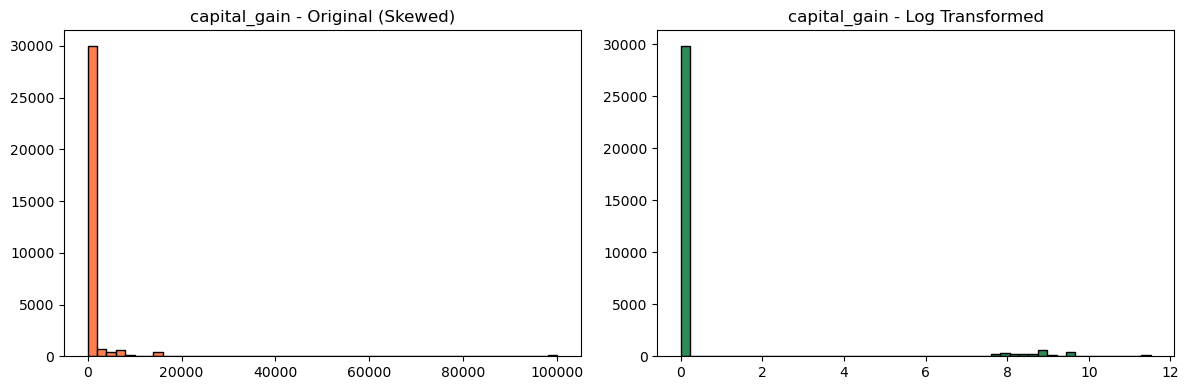

Skewness before: 11.95
Skewness after : 3.1


In [17]:
# ── Log Transformation on capital_gain (highly skewed) ────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['capital_gain'], bins=50, color='coral', edgecolor='black')
plt.title('capital_gain - Original (Skewed)')

# log1p used because many values are 0 (log(0) is undefined)
df_feat['capital_gain_log'] = np.log1p(df['capital_gain'])

plt.subplot(1, 2, 2)
plt.hist(df_feat['capital_gain_log'], bins=50, color='seagreen', edgecolor='black')
plt.title('capital_gain - Log Transformed')
plt.tight_layout()
plt.show()

print("Skewness before:", df['capital_gain'].skew().round(2))
print("Skewness after :", df_feat['capital_gain_log'].skew().round(2))

In [18]:
from sklearn.ensemble import IsolationForest

# Use only numeric columns for Isolation Forest
numeric_df = df_feat.select_dtypes(include='number').drop(columns=['income'])

iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(numeric_df)

# -1 = outlier, 1 = inlier
n_outliers = (outlier_labels == -1).sum()
print(f"Outliers detected: {n_outliers} ({n_outliers/len(df_feat)*100:.1f}%)")

# Remove outliers for a cleaner dataset
df_clean = df_feat[outlier_labels == 1].copy()
print("Dataset shape after outlier removal:", df_clean.shape)

Outliers detected: 1628 (5.0%)
Dataset shape after outlier removal: (30933, 18)


C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 2 members, which is less

PPS Scores (predicting income):
                   x  ppscore
14              age      0.0
29        workclass      0.0
44           fnlwgt      0.0
59        education      0.0
74    education_num      0.0
89   marital_status      0.0
104      occupation      0.0
119    relationship      0.0
134            race      0.0
149             sex      0.0
164    capital_gain      0.0
179    capital_loss      0.0
194  hours_per_week      0.0
209  native_country      0.0


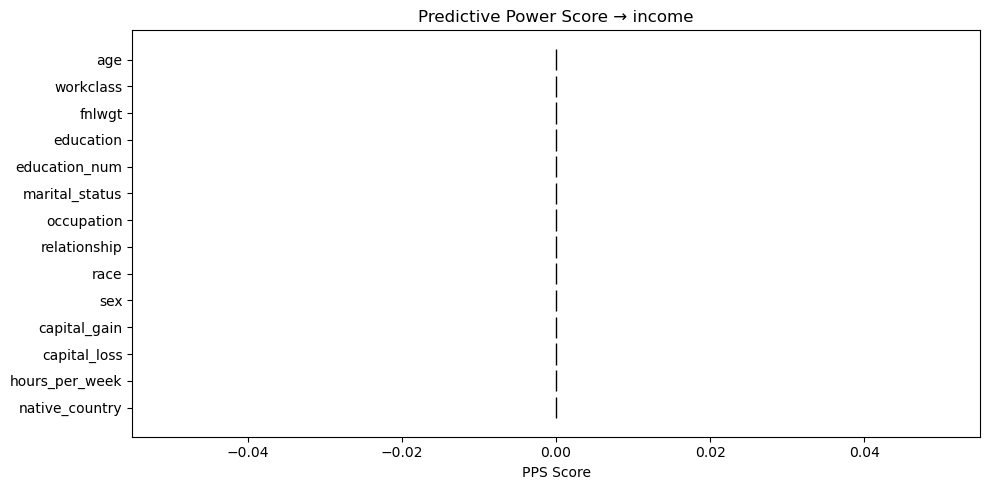

In [19]:
# Install if needed: pip install ppscore
import ppscore as pps

# PPS on original (pre-encoded) data with target
df_pps = df.copy()
df_pps['income'] = (df_pps['income'] == '>50K').astype(int)

pps_matrix = pps.matrix(df_pps)

# Extract scores targeting 'income'
pps_income = pps_matrix[pps_matrix['y'] == 'income'][['x', 'ppscore']]
pps_income = pps_income[pps_income['x'] != 'income'].sort_values('ppscore', ascending=False)

print("PPS Scores (predicting income):\n", pps_income)

# Visualize PPS
plt.figure(figsize=(10, 5))
plt.barh(pps_income['x'], pps_income['ppscore'], color='steelblue', edgecolor='black')
plt.xlabel('PPS Score')
plt.title('Predictive Power Score → income')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

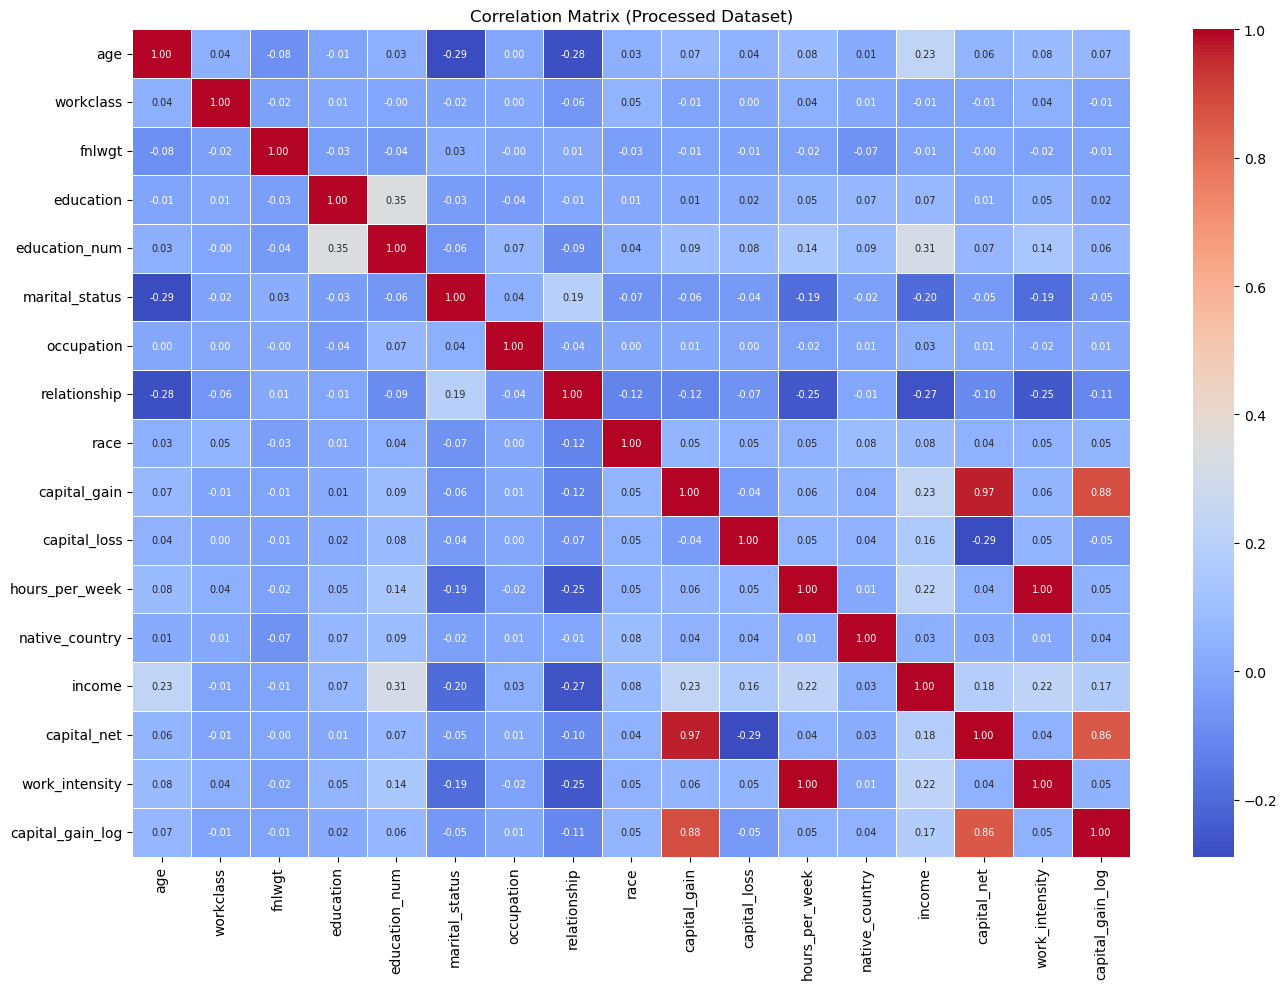

In [20]:
plt.figure(figsize=(14, 10))
corr = df_clean.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix (Processed Dataset)')
plt.tight_layout()
plt.show()